# Convolutional Neural Network
A CNN learns by extracting features from an image, combining them to recognize objects, and continuously adjusting its filters based on prediction errors.

Convolution: A small filter slides over the image. At each position, it compares the filter with the image patch and produces a number indicating how strongly a feature (like an edge or texture) is present.

ReLU Activation: Negative values are replaced with zero, while positive values are kept. This helps the network learn complex patterns.

Pooling: The network keeps only the most important values from small regions, reducing the image size and computational cost while preserving key features.

Flattening: The extracted feature maps are converted into a single vector so they can be processed by the final layers.

Fully Connected Layer: The network combines all the learned features to identify the object in the image.

Softmax: The final outputs are converted into probabilities for each class, and the class with the highest probability is selected as the prediction.

Backpropagation: The prediction is compared with the correct answer, the error is calculated, and the filter weights are updated to improve future predictions.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3535s 21us/step


(50000, 32, 32, 3)

In [3]:
X_test.shape

(10000, 32, 32, 3)

In [4]:
y_train.shape

(50000, 1)

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [6]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [7]:
y_test = y_test.reshape(-1,)

In [8]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [9]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

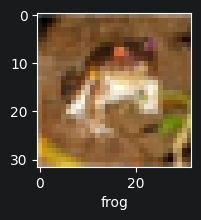

In [10]:
plot_sample(X_train, y_train, 0)

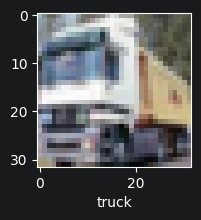

In [11]:
plot_sample(X_train, y_train, 1)

In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [13]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

C:\Users\Diya Dholakia\OneDrive\Desktop\IITB\SOC\Week 3 - Deep Learning and CNN\.venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.3556 - loss: 1.8136
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.4279 - loss: 1.6234
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 60ms/step - accuracy: 0.4561 - loss: 1.5423
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 63ms/step - accuracy: 0.4784 - loss: 1.4808
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.4969 - loss: 1.4309


In [14]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.65      0.37      0.47      1000
           1       0.63      0.62      0.62      1000
           2       0.34      0.47      0.39      1000
           3       0.39      0.23      0.29      1000
           4       0.49      0.27      0.35      1000
           5       0.46      0.31      0.37      1000
           6       0.45      0.65      0.53      1000
           7       0.40      0.72      0.52      1000
           8       0.52      0.72      0.60      1000
           9       0.67      0.43      0.52      1000

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.47     10000
weighted avg       0.50      0.48      0.47     10000



In [15]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\Diya Dholakia\OneDrive\Desktop\IITB\SOC\Week 3 - Deep Learning and CNN\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4717 - loss: 1.4662
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6119 - loss: 1.1036
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6604 - loss: 0.9744
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.6916 - loss: 0.8881
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7162 - loss: 0.8257
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7344 - loss: 0.7694
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.7487 - loss: 0.7252
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7613 - loss: 0.6839
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 26ms/step - accuracy: 0.7770 - loss: 0.6395
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7900 - loss: 0.6012


In [18]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6924 - loss: 0.9415


[0.9414920806884766, 0.6923999786376953]

In [19]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.7185330e-04, 8.6616509e-04, 5.2219960e-03, 9.6779376e-01,
        1.0404012e-04, 1.6459867e-02, 7.4176042e-04, 2.1443119e-04,
        8.2680797e-03, 1.5793172e-04],
       [7.8904545e-03, 8.6276699e-03, 1.4903885e-05, 8.0133225e-09,
        2.7220990e-09, 1.1365710e-11, 1.0356543e-09, 3.2922434e-10,
        9.8345679e-01, 1.0287218e-05],
       [1.2236581e-02, 7.8284210e-01, 2.9828050e-04, 1.1503457e-03,
        2.6380699e-04, 5.4935128e-05, 6.3321822e-06, 7.5278938e-04,
        1.6777338e-01, 3.4621488e-02],
       [8.3509475e-01, 6.2964729e-04, 5.8048755e-02, 1.7147863e-03,
        2.2504926e-03, 2.8463744e-06, 6.9208798e-04, 1.2295970e-03,
        1.0002823e-01, 3.0885293e-04],
       [2.7341700e-06, 2.0018915e-05, 1.0533580e-02, 7.0791014e-02,
        8.6916584e-01, 1.9001368e-03, 4.6665885e-02, 4.8324696e-06,
        9.1440586e-04, 1.5260866e-06]], dtype=float32)

In [20]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(1), np.int64(0), np.int64(4)]

In [21]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

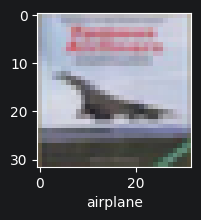

In [22]:
plot_sample(X_test, y_test,3)

In [23]:
classes[y_classes[3]]

'airplane'

In [24]:
classes[y_classes[3]]

'airplane'